**Import Libraries and Load Dataset**

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

# Set plot styles
sns.set(style='whitegrid')


**Load Dataset and Explore**

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


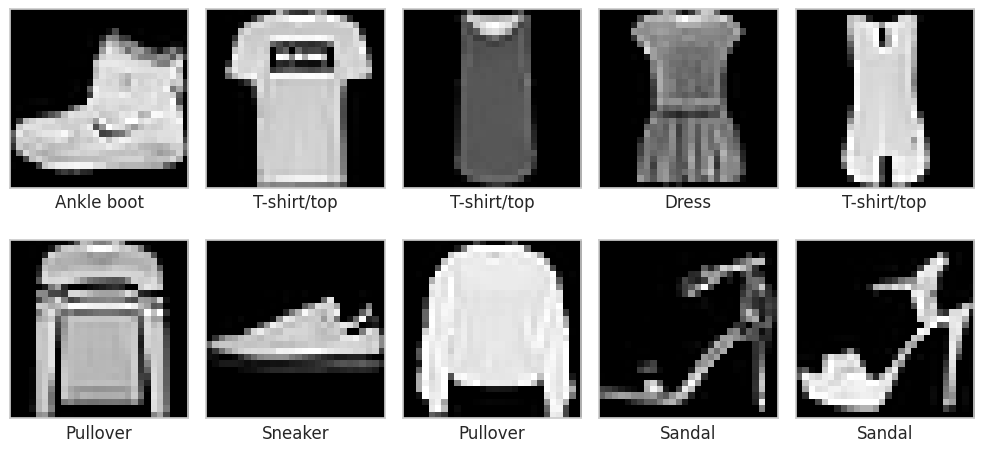

In [2]:
# Load Fashion MNIST dataset directly from Keras
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

# Check shapes
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

# Class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Display a few sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap='gray')
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()


**Preprocess Data (Normalization & Reshaping)**

In [3]:
# Normalize pixel values (0–255 -> 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape data for CNN (add channel dimension)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# For Logistic Regression baseline, flatten images
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)


**Base Model Logistic Regression**

Logistic Regression Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.81      0.80      1000
     Trouser       0.97      0.96      0.96      1000
    Pullover       0.73      0.74      0.73      1000
       Dress       0.83      0.86      0.84      1000
        Coat       0.74      0.76      0.75      1000
      Sandal       0.94      0.92      0.93      1000
       Shirt       0.63      0.57      0.60      1000
     Sneaker       0.91      0.94      0.92      1000
         Bag       0.93      0.93      0.93      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



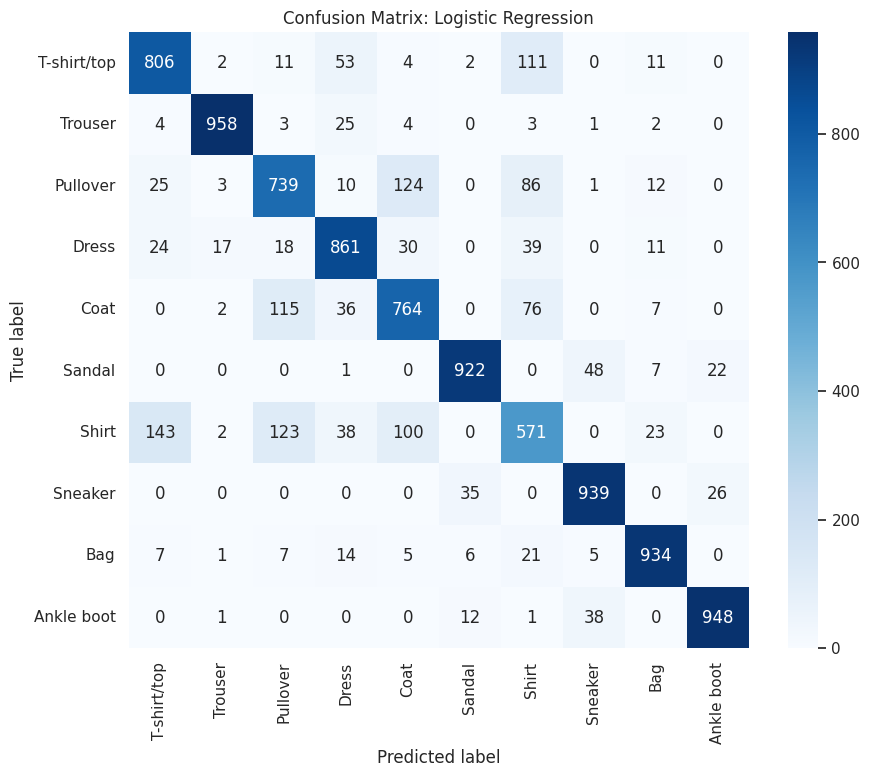

In [4]:
# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1)

# Train model
log_reg.fit(X_train_flat, y_train)

# Evaluate model
y_pred_log = log_reg.predict(X_test_flat)

# Classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log, target_names=class_names))

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(10,8))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix: Logistic Regression")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


**Building  CNN Model**

In [23]:
from tensorflow.keras import layers, models

In [24]:
# Build enhanced CNN model
enhanced_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Compile model
enhanced_cnn_model.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

In [26]:
# Model summary
enhanced_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

**Train CNN Model**

In [27]:
# Train the enhanced CNN model
history_enhanced = enhanced_cnn_model.fit(X_train_cnn, y_train, epochs=15, validation_split=0.1)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 118s 67ms/step - accuracy: 0.7712 - loss: 0.6692 - val_accuracy: 0.8822 - val_loss: 0.3230
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 109s 65ms/step - accuracy: 0.8728 - loss: 0.3628 - val_accuracy: 0.8950 - val_loss: 0.2841
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 141s 64ms/step - accuracy: 0.8888 - loss: 0.3128 - val_accuracy: 0.8888 - val_loss: 0.2996
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.8962 - loss: 0.2925 - val_accuracy: 0.9105 - val_loss: 0.2387
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 140s 65ms/step - accuracy: 0.9020 - loss: 0.2734 - val_accuracy: 0.9143 - val_loss: 0.2755
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 108s 64ms/step - accuracy: 0.9076 - loss: 0.2604 - val_accuracy: 0.9058 - val_loss: 0.2836
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 142s 64ms/step - accuracy: 0.9107 - loss: 0.2508 - val_accuracy: 0.9162 - val_loss: 0.2292
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 142s 64ms/step - accuracy: 

**Evaluate CNN Model**

In [28]:
# Evaluate on test data
test_loss, test_acc = enhanced_cnn_model.evaluate(X_test_cnn, y_test)
print(f'Test accuracy (Enhanced CNN): {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9233 - loss: 0.2208
Test accuracy (Enhanced CNN): 0.9232


In [29]:
# Predictions
y_pred_enhanced = np.argmax(enhanced_cnn_model.predict(X_test_cnn), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [43]:
# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("CNN Classification Report:")
print(classification_report(y_test, y_pred_enhanced, target_names=class_names))

CNN Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.86      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.85      0.91      0.88      1000
       Dress       0.91      0.94      0.92      1000
        Coat       0.89      0.86      0.87      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.79      0.76      0.78      1000
     Sneaker       0.95      0.99      0.97      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.99      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



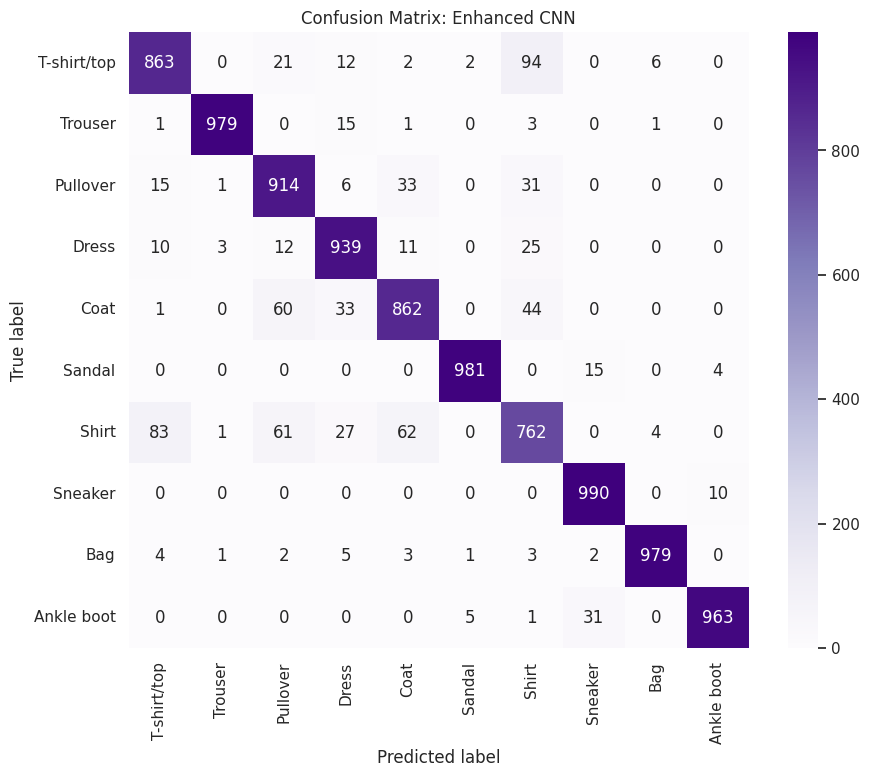

In [31]:
# Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, y_pred_enhanced), annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix: Enhanced CNN")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

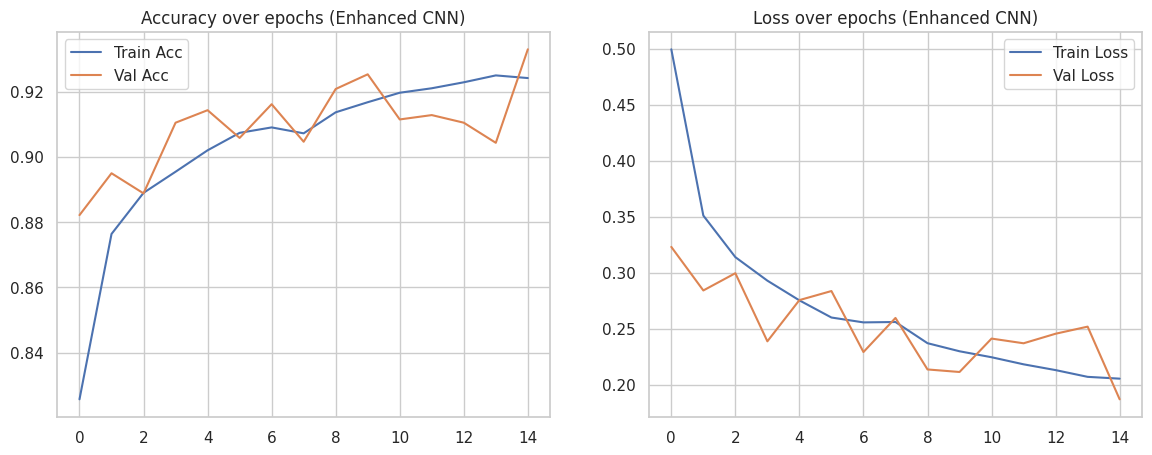

In [32]:
# Plot training history
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(history_enhanced.history['accuracy'], label='Train Acc')
plt.plot(history_enhanced.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy over epochs (Enhanced CNN)')

plt.subplot(1,2,2)
plt.plot(history_enhanced.history['loss'], label='Train Loss')
plt.plot(history_enhanced.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss over epochs (Enhanced CNN)')
plt.show()

**Apply Data Augmentation and Retrain CNN**

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [34]:
from sklearn.model_selection import train_test_split

# Manually split training and validation sets (90% train, 10% validation)
X_train_gen, X_val_gen, y_train_gen, y_val_gen = train_test_split(
    X_train_cnn, y_train, test_size=0.1, random_state=42
)


In [35]:
# Define data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [36]:
# Fit generator to training data
datagen.fit(X_train_gen)

In [37]:
# Retrain model with augmentation
history_aug = enhanced_cnn_model.fit(
    datagen.flow(X_train_gen, y_train_gen, batch_size=64),
    validation_data=(X_val_gen, y_val_gen),
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 114s 135ms/step - accuracy: 0.7891 - loss: 0.5990 - val_accuracy: 0.8722 - val_loss: 0.3147
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 115s 136ms/step - accuracy: 0.8314 - loss: 0.4579 - val_accuracy: 0.8453 - val_loss: 0.3829
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 114s 135ms/step - accuracy: 0.8419 - loss: 0.4317 - val_accuracy: 0.9077 - val_loss: 0.2396
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 113s 134ms/step - accuracy: 0.8481 - loss: 0.4155 - val_accuracy: 0.9147 - val_loss: 0.2255
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 116s 137ms/step - accuracy: 0.8530 - loss: 0.4001 - val_accuracy: 0.8860 - val_loss: 0.2829
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 116s 138ms/step - accuracy: 0.8568 - loss: 0.3958 - val_accuracy: 0.8953 - val_loss: 0.2571
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 113s 134ms/step - accuracy: 0.8592 - loss: 0.3837 - val_accuracy: 0.8917 - val_loss: 0.2747
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 115s 136ms/step - accuracy: 0.8622 - loss: 0.37

In [38]:
# Make predictions on the test set
y_pred_probs = enhanced_cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [39]:
import pandas as pd

# Create a DataFrame with prediction results
results_df = pd.DataFrame({
    'Image_Index': np.arange(len(y_test)),
    'True_Label': y_test,
    'Predicted_Label': y_pred
})

# Add column "Result" → Correct or Wrong
results_df['Result'] = np.where(results_df['True_Label'] == results_df['Predicted_Label'],
                                 'Correct', 'Wrong')

# Optional (if you want readable class names instead of integers)
results_df['True_Label_Name'] = results_df['True_Label'].map(lambda x: class_names[x])
results_df['Predicted_Label_Name'] = results_df['Predicted_Label'].map(lambda x: class_names[x])

# Reorder columns (for clarity)
results_df = results_df[['Image_Index', 'True_Label', 'True_Label_Name',
                         'Predicted_Label', 'Predicted_Label_Name', 'Result']]

In [40]:
# Show first 10 rows
results_df.head(10)

,Image_Index,True_Label,True_Label_Name,Predicted_Label,Predicted_Label_Name,Result
0,0,9,Ankle boot,9,Ankle boot,Correct
1,1,2,Pullover,2,Pullover,Correct
2,2,1,Trouser,1,Trouser,Correct
3,3,1,Trouser,1,Trouser,Correct
4,4,6,Shirt,6,Shirt,Correct
5,5,1,Trouser,1,Trouser,Correct
6,6,4,Coat,4,Coat,Correct
7,7,6,Shirt,6,Shirt,Correct
8,8,5,Sandal,5,Sandal,Correct
9,9,7,Sneaker,7,Sneaker,Correct


In [41]:
# Count of Correct vs Wrong predictions
results_df['Result'].value_counts()

,count
Result,
Correct,9049
Wrong,951
